# Véletlenszerű játszma Stockfish-elemzése + LLM narráció API hívással

**Pipeline:**
1. Véletlenszerű játszma sorsolása a `mychessdotcomgames.parquet` fájlból
2. Stockfish elemzés (centipawn annotációk lépésenként)
3. Annotált PGN exportálása → `output/llm-analysis/elemzett.pgn`
4. LLM API: didaktikus narráció generálása (provider: `config.LLM_PROVIDER`)
5. Narráció mentése → `output/llm-analysis/szoveges/{llm_provider}_{game_id}.txt`
6. TTS hangfájl generálása → `output/llm-analysis/hangos_narracio/{llm_provider}_{game_id}.mp3`

In [1]:
import subprocess, sys, os

root_dir = os.getcwd() if os.path.exists(os.path.join(os.getcwd(), "config.py")) \
    else os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, root_dir)
import config

if not os.path.exists(config.GAMES_PARQUET):
    print("Parquet fájl nem található – pipeline futtatása...")
    result = subprocess.run(
        [sys.executable, os.path.join(root_dir, "src", "run_pipeline.py"), "--pgn", config.PGN_FILE],
        cwd=root_dir,
    )
    if result.returncode != 0:
        raise RuntimeError("Pipeline futtatása sikertelen! Ellenőrizd a PGN fájlt és a config.py-t.")
    print("✅ Pipeline kész.")
else:
    print(f"✅ Parquet már megvan: {config.GAMES_PARQUET}")

✅ Parquet már megvan: D:\Workspace\chess-pgn-analysis\output\parquet\mychessdotcomgames.parquet


In [2]:
import os
import sys
import random
import shutil

# ROOT_DIR: a könyvtár ahol a config.py van
_cwd = os.getcwd()
ROOT_DIR = _cwd if os.path.exists(os.path.join(_cwd, "config.py"))            else os.path.abspath(os.path.join(_cwd, ".."))
sys.path.insert(0, ROOT_DIR)

import polars as pl
import chess
import chess.pgn
import chess.engine

import config
from src.llm_client import generate_text

print(f"ROOT_DIR    : {ROOT_DIR}")
print(f"LLM provider: {config.LLM_PROVIDER}  ({config.LLM_MODEL})")
print(f"API kulcs   : {chr(39)+chr(79)+chr(75)+chr(39) if config.LLM_API_KEY else chr(39)+'HIÁNYZIK – töltsd ki a secrets.py-t!'+chr(39)}")

ROOT_DIR    : D:\Workspace\chess-pgn-analysis
LLM provider: openai  (gpt-4o)
API kulcs   : 'OK'


## 1. Véletlen játszma kiválasztása

In [3]:
PARQUET_PATH = os.path.join(ROOT_DIR, "output", "parquet", "mychessdotcomgames.parquet")

df = pl.read_parquet(PARQUET_PATH)
print(f"Összes játszma a parquet-ban: {len(df):,}")

idx = random.randint(0, len(df) - 1)
row = df.row(idx, named=True)

print(f"\nKiválasztott játszma (sor-index={idx}, game_id={row['game_id']}):")
print(f"  Fehér  : {row['white']} ({row['white_elo']})")
print(f"  Fekete : {row['black']} ({row['black_elo']})")
print(f"  Megnyitó: {row['eco']} · {row['opening']}")
print(f"  Eredmény: {row['result']}  |  Lépések: {row['num_moves']}")

Összes játszma a parquet-ban: 1,377

Kiválasztott játszma (sor-index=618, game_id=619):
  Fehér  : Wujajin (1088)
  Fekete : gganeshgupta (1056)
  Megnyitó: D00 · 
  Eredmény: 1-0  |  Lépések: 92


## 2. Stockfish elemzés: heurisztika az LLM-nek!

A kisebb depth gyorsabb futást eredményez, de a magasabb alaposabb (pontosabb) elemzést!

In [4]:
def find_stockfish() -> str:
    if getattr(config, 'STOCKFISH_PATH', None) and os.path.isfile(config.STOCKFISH_PATH):
        return config.STOCKFISH_PATH
    bundled = os.path.join(ROOT_DIR, "stockfish", "stockfish-windows-x86-64-avx2.exe")
    if os.path.isfile(bundled):
        return bundled
    found = shutil.which("stockfish")
    if found:
        return found
    raise FileNotFoundError("Stockfish nem található! Ellenőrizd a stockfish/ mappát.")

SF_PATH = find_stockfish()
print(f"Stockfish: {SF_PATH}")

Stockfish: D:\Workspace\chess-pgn-analysis\stockfish\stockfish-windows-x86-64-avx2.exe


In [5]:
import asyncio
from tqdm.notebook import tqdm

if hasattr(asyncio, 'WindowsProactorEventLoopPolicy'):
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

DEPTH       = 12
MOVES_LIMIT = config.STOCKFISH_MOVES_LIMIT

moves_uci_list = row['moves_uci'].strip().split()
to_analyze     = min(len(moves_uci_list), MOVES_LIMIT)
print(f"Elemzés: mélység={DEPTH}, lépések={to_analyze}/{len(moves_uci_list)}\n")

board       = chess.Board()
evaluations = []

with chess.engine.SimpleEngine.popen_uci(SF_PATH) as engine:
    limit = chess.engine.Limit(depth=DEPTH)

    for i, uci in enumerate(tqdm(moves_uci_list[:MOVES_LIMIT], desc="Stockfish", unit="lépés")):
        move = chess.Move.from_uci(uci)
        if move not in board.legal_moves:
            print(f"  Illegális lépés: {uci} – leállítás")
            break

        san = board.san(move)
        board.push(move)

        info  = engine.analyse(board, limit)
        score = info["score"].white()

        evaluations.append({
            "move_number": (i // 2) + 1,
            "color":       "white" if i % 2 == 0 else "black",
            "uci":         uci,
            "san":         san,
            "cp":          score.score(mate_score=10000),
            "mate":        score.mate(),
            "fen":         board.fen(),   # állás a lépés UTÁN – Streamlit-anchor
        })

print(f"\nKész: {len(evaluations)} lépés elemezve.")


Elemzés: mélység=12, lépések=92/92



Stockfish:   0%|          | 0/92 [00:00<?, ?lépés/s]


Kész: 92 lépés elemezve.


## 3. Annotált PGN exportálása

In [6]:
game_id   = row["game_id"]
os.makedirs(config.LLM_ANALYSIS_DIR, exist_ok=True)
PGN_PATH  = config.ELEMZETT_PGN

# Duplikátum-ellenőrzés
pgn_exists     = os.path.exists(PGN_PATH) and os.path.getsize(PGN_PATH) > 0
already_in_pgn = False
if pgn_exists:
    with open(PGN_PATH, encoding="utf-8") as f:
        if f'[ParquetGameId "{game_id}"]' in f.read():
            already_in_pgn = True

if already_in_pgn:
    print(f"⚠️  Játszma #{game_id} már szerepel az elemzett.pgn-ben – kihagyva.")
else:
    game_pgn = chess.pgn.Game()
    game_pgn.headers.update({
        "Event":         row.get("event",    "?"),
        "Site":          row.get("site",     "?"),
        "Date":          row.get("date",     "?"),
        "White":         row.get("white",    "?"),
        "Black":         row.get("black",    "?"),
        "Result":        row.get("result",   "*"),
        "WhiteElo":      str(row.get("white_elo", "?")),
        "BlackElo":      str(row.get("black_elo", "?")),
        "ECO":           row.get("eco",      "?"),
        "Opening":       row.get("opening",  "?"),
        "ParquetGameId": str(game_id),
    })

    node = game_pgn
    for ev in evaluations:
        node = node.add_variation(chess.Move.from_uci(ev["uci"]))
        if ev["mate"] is not None:
            node.comment = f"[%eval #{ev['mate']}]"
        elif ev["cp"] is not None:
            node.comment = f"[%eval {ev['cp'] / 100:.2f}]"

    # Stockfish-határon túli lépések annotáció nélkül – a PGN mindig teljes legyen
    for uci in moves_uci_list[len(evaluations):]:
        node = node.add_variation(chess.Move.from_uci(uci))

    # StringExporter garantál egységes kimenetet; .strip()+"\n" pontosan egy \n-re zárja a játszmát.
    # Ha már van tartalom, egy "\n" elé kerül → mindig pontosan egy üres sor lesz a játszmák között.
    pgn_str = game_pgn.accept(chess.pgn.StringExporter(headers=True, variations=True, comments=True))
    with open(PGN_PATH, "a", encoding="utf-8") as f:
        if pgn_exists:
            f.write("\n")
        f.write(pgn_str.strip() + "\n")

    with open(PGN_PATH, encoding="utf-8") as f:
        content = f.read()
    game_count = content.count("[Event ")
    print(f"PGN hozzáfűzve: {PGN_PATH}")
    print(f"Összes elemzett játszma: {game_count}")
    print("\nUtolsó hozzáfűzött játszma (első 600 karakter):")
    last_start = content.rfind("[Event ")
    print(content[last_start:last_start + 600])

PGN hozzáfűzve: D:\Workspace\chess-pgn-analysis\output\llm-analysis\elemzett.pgn
Összes elemzett játszma: 1

Utolsó hozzáfűzött játszma (első 600 karakter):
[Event "Live Chess"]
[Site "Chess.com"]
[Date "2025.11.08"]
[Round "?"]
[White "Wujajin"]
[Black "gganeshgupta"]
[Result "1-0"]
[WhiteElo "1088"]
[BlackElo "1056"]
[ECO "D00"]
[Opening ""]
[ParquetGameId "619"]

1. d4 { [%eval 0.30] } 1... d5 { [%eval 0.38] } 2. Nc3 { [%eval 0.03] } 2... e6
{ [%eval 0.49] } 3. Bf4 { [%eval 0.07] } 3... Nc6 { [%eval 0.37] } 4. Nb5
{ [%eval 0.07] } 4... Bd7 { [%eval 4.03] } 5. Nxc7+ { [%eval 4.01] } 5... Ke7
{ [%eval 4.10] } 6. Nxa8 { [%eval 4.10] } 6... e5 { [%eval 4.58] } 7. dxe5
{ [%eval 4.62] } 7... Qxa8 { [%eval 4.81] } 8. e3 { [%eval 4.94] } 8... Qb8
{ [%e


## 4. LLM narráció generálása

In [7]:
import json as _json
import sys, os
sys.path.insert(0, ROOT_DIR)
from src.narrator import generate_narration

game_data = {
    "white":     row.get("white",    "Fehér"),
    "black":     row.get("black",    "Fekete"),
    "white_elo": row.get("white_elo", "?"),
    "black_elo": row.get("black_elo", "?"),
    "eco":       row.get("eco",      "?"),
    "opening":   row.get("opening",  ""),
    "result":    row.get("result",   "*"),
}

narration_json = generate_narration(game_data, evaluations)

print("✅ JSON parse sikeres.")
for i, para in enumerate(narration_json.get("paragraphs", []), 1):
    print(f"\n--- {i}. bekezdés ---")
    print(para["text"])
    anchors = para.get("anchors", [])
    print(f"  ({len(anchors)} anchor)")
    for anc in anchors:
        tw = anc.get("trigger_word", "")
        if tw and tw not in para["text"]:
            print(f"  ⚠️  BROKEN trigger_word (nem szerepel a szövegben): '{tw}'")

✅ JSON parse sikeres.

--- 1. bekezdés ---
A játszma a nyitólépésektől kezdve izgalmas alakot öltött. Fehér a klasszikus 1.d4 gyaloglépéssel nyitott, amely a centrum gyors ellenőrzésére irányul. Fekete válaszolt a két hagyományos megnyitás közül egyike, a Vezérgyalog játék (d5) lépéssel. Mindkét fél jól kezdett, ám már korán látszott, hogy fehér agresszívan fog játszani az 2.Nc3-tal, ami a királyi huszárt fejleszti és kiegészíti a centrum kontrollját.
  (2 anchor)
  ⚠️  BROKEN trigger_word (nem szerepel a szövegben): 'Fehér agresszívan fog játszani'

--- 2. bekezdés ---
A megnyitás némi meglepetést tartogatott. Fekete 4...Bd7 lépése ★ súlyos hibának bizonyult, hiszen a huszár támadásával szemben egy teljesen védtelen paraszti állás alakul ki. Fehér azonnal kihasználta ezt a hibát a 5.Nxc7+ közbeiktatott sakkal, ami az ellenfél királyának mozgását korlátozta és tovább növelte pozíciós előnyét. Az ezt követő 6.Nxa8 lépéssel fehér további anyagi előnyre tett szert, mivel elkapta a fekete 

## 5. Narráció mentése

In [8]:
import json as _json
import chess as _chess

if narration_json is None:
    print("⚠️  Nincs valid JSON narráció – mentés kihagyva.")
else:
    llm_name = config.LLM_PROVIDER
    json_name = f"{llm_name}_{game_id}.json"
    txt_name  = f"{llm_name}_{game_id}.txt"

    os.makedirs(config.LLM_ANALYSIS_JSON_DIR, exist_ok=True)
    os.makedirs(config.LLM_ANALYSIS_SZOVEGES_DIR, exist_ok=True)

    JSON_PATH = os.path.join(config.LLM_ANALYSIS_JSON_DIR, json_name)
    LLM_PATH  = os.path.join(config.LLM_ANALYSIS_SZOVEGES_DIR, txt_name)

    # 'moves' mező: a Streamlit slideshow-hoz az összes lépés FEN-je sorrendben.
    # Az index 0 = kezdőállás, 1..N = az evaluations egyes lépései utáni állások.
    moves_for_json = [{"move_number": 0, "color": "start", "san": "", "fen": _chess.STARTING_FEN}]
    moves_for_json += [
        {
            "move_number": e["move_number"],
            "color":       e["color"],
            "san":         e["san"],
            "fen":         e["fen"],
        }
        for e in evaluations
    ]
    narration_json["moves"] = moves_for_json

    # JSON fájl (FEN-anchorokat + összes lépést tartalmaz – Streamlit-nek)
    with open(JSON_PATH, "w", encoding="utf-8") as f:
        _json.dump(narration_json, f, ensure_ascii=False, indent=2)
    print(f"JSON narráció elmentve: {JSON_PATH}")
    print(f"  → {len(moves_for_json)} lépés FEN mentve (moves mező)")

    # TTS szöveges fájl (csak a text mezők, anchor nélkül)
    tts_text = "\n\n".join(
        para["text"] for para in narration_json.get("paragraphs", [])
    )
    with open(LLM_PATH, "w", encoding="utf-8") as f:
        f.write(tts_text)
    print(f"TTS szöveg elmentve: {LLM_PATH}")
    print(f"\nTTS szöveg előnézete:")
    print(tts_text[:400], "..." if len(tts_text) > 400 else "")


JSON narráció elmentve: D:\Workspace\chess-pgn-analysis\output\llm-analysis\json_narracio\openai_619.json
  → 93 lépés FEN mentve (moves mező)
TTS szöveg elmentve: D:\Workspace\chess-pgn-analysis\output\llm-analysis\szoveges\openai_619.txt

TTS szöveg előnézete:
A játszma a nyitólépésektől kezdve izgalmas alakot öltött. Fehér a klasszikus 1.d4 gyaloglépéssel nyitott, amely a centrum gyors ellenőrzésére irányul. Fekete válaszolt a két hagyományos megnyitás közül egyike, a Vezérgyalog játék (d5) lépéssel. Mindkét fél jól kezdett, ám már korán látszott, hogy fehér agresszívan fog játszani az 2.Nc3-tal, ami a királyi huszárt fejleszti és kiegészíti a centrum  ...


## 6. TTS hangfájl generálása (kicsit lassabban fut!)

In [9]:
from src.tts_client import generate_audio

mp3_name = txt_name.replace(".txt", ".mp3")
os.makedirs(config.LLM_ANALYSIS_HANGOS_DIR, exist_ok=True)
MP3_PATH = os.path.join(config.LLM_ANALYSIS_HANGOS_DIR, mp3_name)

if os.path.exists(MP3_PATH):
    print(f"⚠️  Hangfájl már létezik: {MP3_PATH} – kihagyva.")
else:
    with open(LLM_PATH, encoding="utf-8") as f:
        narration_text = f.read()
    generate_audio(narration_text, MP3_PATH, show_progress=True)
    print(f"Hangfájl elmentve: {MP3_PATH}  ({os.path.getsize(MP3_PATH):,} bájt)")

TTS letöltés (OpenAI): 0.00B [00:00, ?B/s]

Hangfájl elmentve: D:\Workspace\chess-pgn-analysis\output\llm-analysis\hangos_narracio\openai_619.mp3  (2,316,480 bájt)


## 7. Végső állás – sakktábla

Az utolsó FEN-anchor alapján.

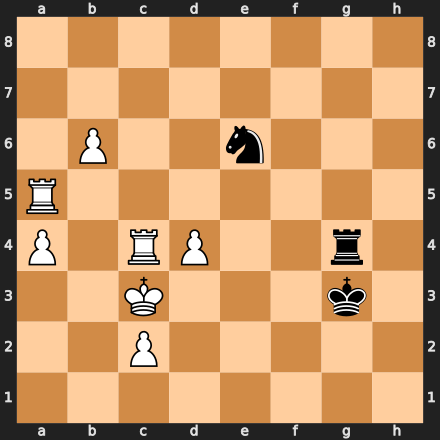

In [10]:
import chess
import chess.svg
import chess.pgn
from IPython.display import SVG, HTML, display

_last_fen = None
if narration_json and narration_json.get("paragraphs"):
    for _para in reversed(narration_json["paragraphs"]):
        for _anchor in reversed(_para.get("anchors", [])):
            if _anchor.get("fen"):
                _last_fen = _anchor["fen"]
                break
        if _last_fen:
            break

if _last_fen:
    _board = chess.Board(_last_fen)
    display(SVG(chess.svg.board(_board, size=440)))

    display(HTML(f"""
<div style="
    display: inline-block;
    margin-top: 10px;
    padding: 9px 18px;
    background: #A81022;
    border-radius: 10px;
    box-shadow: 0 3px 10px rgba(0,0,0,0.35);
    font-family: 'Courier New', monospace;
    color: #ffffff;
    font-size: 13px;
    min-width: 600px;
    white-space: nowrap;
">
    <span style="
        display: block;
        color: rgba(255,255,255,0.8);
        font-family: 'Segoe UI', sans-serif;
        font-size: 10px;
        font-weight: 700;
        letter-spacing: 1.5px;
        margin-bottom: 4px;
    ">FEN</span>
    {_last_fen}
</div>
"""))

    # Annotált PGN rekonstruálása az evaluations adatokból
    _pgn_game = chess.pgn.Game()
    _pgn_game.headers.update({
        "Event":    row.get("event",   "?"),
        "Site":     row.get("site",    "?"),
        "Date":     row.get("date",    "?"),
        "White":    row.get("white",   "?"),
        "Black":    row.get("black",   "?"),
        "Result":   row.get("result",  "*"),
        "WhiteElo": str(row.get("white_elo", "?")),
        "BlackElo": str(row.get("black_elo", "?")),
        "ECO":      row.get("eco",     "?"),
        "Opening":  row.get("opening", "?"),
    })
    _node = _pgn_game
    for _ev in evaluations:
        _node = _node.add_variation(chess.Move.from_uci(_ev["uci"]))
        if _ev["mate"] is not None:
            _node.comment = f"[%eval #{_ev['mate']}]"
        elif _ev["cp"] is not None:
            _node.comment = f"[%eval {_ev['cp'] / 100:.2f}]"
    _pgn_str = _pgn_game.accept(chess.pgn.StringExporter(headers=True, variations=True, comments=True))

    display(HTML(f"""
<div style="
    display: inline-block;
    margin-top: 10px;
    padding: 12px 18px;
    background: #12232e;
    border-radius: 10px;
    box-shadow: 0 3px 10px rgba(0,0,0,0.35);
    font-family: 'Courier New', monospace;
    color: #e0e0e0;
    font-size: 12px;
    min-width: 600px;
    max-width: 800px;
">
    <span style="
        display: block;
        color: rgba(255,255,255,0.6);
        font-family: 'Segoe UI', sans-serif;
        font-size: 10px;
        font-weight: 700;
        letter-spacing: 1.5px;
        margin-bottom: 8px;
    ">ANNOTÁLT PGN · Stockfish mélység {DEPTH}</span>
    <pre style="margin:0; white-space: pre-wrap; word-break: break-word; line-height: 1.6;">{_pgn_str}</pre>
</div>
"""))

    display(HTML(f"""
<div style="
    display: inline-block;
    margin-top: 10px;
    padding: 10px 28px;
    background: linear-gradient(135deg, #1a73e8 0%, #0d47a1 100%);
    border-radius: 12px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.25);
    font-family: 'Segoe UI', sans-serif;
    color: #ffffff;
    font-size: 18px;
    font-weight: 600;
    letter-spacing: 0.5px;
">
    🎲 Sorsolva: <span style="font-size:22px; font-weight:800;">#{game_id}. játszma</span>
</div>
"""))
else:
    display(HTML("<p style='color:gray'>Nincs megjeleníthető FEN – futtasd le előbb a narráció-generáló cellát!</p>"))